# 04: Marginal Structural Model for Long-Term Effects

The first three notebooks built the causal analysis foundation:

- Notebook 01 turned KuaiRec into a sequential user-day panel.
- Notebook 02 defined the primary estimand.
- Notebook 03 modeled treatment assignment and created stabilized inverse probability weights.

This notebook is the first one that estimates the primary long-term causal effect. The question asks the following.

> Among active KuaiRec user-days with sufficient prior history and 7-day follow-up, what is the effect of a high-watch-exposure day on future 7-day interaction volume?

The method used here is a **marginal structural model**. The key idea is simple. We use inverse probability weights to create a pseudo-population where observed pre-treatment histories are more balanced across treatment groups. In that weighted pseudo-population, a regression of future outcome on treatment estimates a marginal treatment effect.


<!-- dataset-experiment-context -->
## Dataset and Sequential Design Context

This project uses KuaiRec interaction logs organized into a user-day panel. The raw data contain user-video interactions, watch behavior, user features, item metadata, and item daily popularity information.

The data come from a real observational sequential recommendation log. Daily exposure was created by the recommender system, so assignment must be treated as time-varying and confounded. The treatment is a constructed high-watch-exposure day, the primary outcome is future seven-day engagement, and lagged user behavior is both a predictor of treatment and a predictor of future outcomes.

The project studies a sequential causal question: whether short-term exposure is associated with later engagement after adjusting for observed history. Marginal structural models, g-computation, doubly robust estimation, overlap diagnostics, and heterogeneity checks are used to decide whether the evidence is credible enough to motivate a future online test.

**Role of this notebook.** This notebook uses stabilized inverse probability weights to estimate a marginal structural model for the long-term exposure effect.

<!-- mathematical-setup -->

## Mathematical Setup

A marginal structural model describes the mean potential outcome under treatment regimes. For a single treatment time, the working model can be written as

$$
\mathbb{E}[Y_i(a)] = \beta_0 + \beta_1 a.
$$

The weighted estimating equation solves a regression using inverse-probability weights:

$$
\sum_i SW_i X_i\{Y_i-X_i^\top\beta\}=0.
$$

Here \(\beta_1\) estimates the marginal effect of short-term high-watch exposure after reweighting the observed panel to reduce time-varying confounding. Cluster-robust uncertainty is used because repeated observations from the same user are correlated.


## What This Step Adds

Notebook 03 created treatment weights. This notebook uses them to estimate effects and uncertainty.

The notebook covers:

1. naive unweighted treated-control comparisons;
2. weighted treated-control comparisons;
3. weighted least-squares marginal structural models;
4. user-cluster robust standard errors;
5. user-cluster bootstrap confidence intervals;
6. sensitivity to weight choice and clipping;
7. secondary outcomes such as future active days and watch hours.

The goal is to make a defensible estimate from observed sequential logs while clearly showing where uncertainty and sensitivity remain.


#### Setup

This cell imports the libraries used for weighted regression, bootstrap uncertainty, tables, and plots. `statsmodels` is used because it exposes weighted least squares and cluster-robust standard errors, which are both important for this notebook.


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
import statsmodels.api as sm

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42


The notebook environment is ready for weighted effect estimation. The important addition compared with earlier notebooks is `statsmodels`, which lets us fit marginal structural regressions and compute user-cluster robust uncertainty.


#### Locate the Weighted Panel

Notebook 03 saved the weighted panel to `data/processed`. This notebook starts from that saved table so the treatment assignment work remains separate from the effect-estimation work.


In [2]:
WEIGHTED_PANEL_RELATIVE_PATH = Path("data/processed/kuairec_long_term_weighted_panel.parquet")

candidate_roots = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next(
    (path for path in candidate_roots if (path / WEIGHTED_PANEL_RELATIVE_PATH).exists()),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        f"Could not find {WEIGHTED_PANEL_RELATIVE_PATH}. Run Notebook 03 first or run this notebook inside the project."
    )

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PANEL_PATH = PROJECT_ROOT / WEIGHTED_PANEL_RELATIVE_PATH

print(f"Project root: {PROJECT_ROOT}")
print(f"Weighted panel: {PANEL_PATH}")
print(f"Processed output folder: {PROCESSED_DIR}")


The paths confirm that this notebook is connected to the weighted panel produced in Notebook 03. That keeps the project sequence clean. This notebook estimates effects using the saved propensity-model outputs.


#### Load and Validate the Weighted Panel

The weighted panel should contain the primary treatment, primary outcome, propensity scores, and analysis weights. The next cell loads the data and verifies those required columns.


In [3]:
# Load and validate the weighted panel.
panel = pd.read_parquet(PANEL_PATH)
panel["event_date"] = pd.to_datetime(panel["event_date"])
panel = panel.sort_values(["user_id", "event_date"]).reset_index(drop=True)

PRIMARY_TREATMENT = "treatment"
PRIMARY_OUTCOME = "outcome"
PRIMARY_WEIGHT = "analysis_weight"

required_columns = [
    "user_id",
    "event_date",
    "day_of_week",
    PRIMARY_TREATMENT,
    PRIMARY_OUTCOME,
    PRIMARY_WEIGHT,
    "sw_logistic",
    "sw_lightgbm",
    "propensity_logistic",
    "propensity_lightgbm",
]

missing_required = [column for column in required_columns if column not in panel.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

print(f"Panel shape: {panel.shape}")
print(f"Users: {panel['user_id'].nunique():,}")
print(f"Date range: {panel['event_date'].min().date()} to {panel['event_date'].max().date()}")
display(panel[required_columns].head())


Panel shape: (4698, 40)
Users: 91
Date range: 2020-07-08 to 2020-08-29


,user_id,event_date,day_of_week,treatment,outcome,analysis_weight,sw_logistic,sw_lightgbm,propensity_logistic,propensity_lightgbm
0,14,2020-07-08,Wednesday,1,279.0000,0.9131,0.9131,0.9487,0.5471,0.5266
1,14,2020-07-09,Thursday,0,311.0000,1.3647,1.3647,1.0816,0.6333,0.5373
2,14,2020-07-10,Friday,1,352.0000,1.2067,1.2067,0.9544,0.4140,0.5234
3,14,2020-07-11,Saturday,1,437.0000,0.8836,0.8836,0.7682,0.5654,0.6503
4,14,2020-07-12,Sunday,0,437.0000,1.2466,1.2466,1.9378,0.5986,0.7418


The weighted panel has the columns needed for marginal structural modeling. Each row is a user-day, and repeated rows per user are expected, which is why later uncertainty estimates cluster by `user_id`.


### Restate the Estimand and Modeling Columns

This table keeps the causal target visible. The treatment and outcome are the standardized columns created in Notebook 02, while the weight is the stabilized propensity weight selected in Notebook 03.


In [4]:
msm_design = pd.DataFrame(
    [
        {"component": "unit", "definition": "A KuaiRec user-day in the final estimand population."},
        {"component": "treatment", "definition": "treatment = 1 for a high-watch-exposure day."},
        {"component": "control", "definition": "treatment = 0 for an active user-day below the high-watch exposure rule."},
        {"component": "outcome", "definition": "outcome = future 7-day interaction volume."},
        {"component": "primary weight", "definition": "analysis_weight = stabilized logistic propensity weight clipped at 10."},
        {"component": "uncertainty unit", "definition": "Cluster by user_id because users contribute repeated days."},
    ]
)

display(msm_design)


,component,definition
0,unit,A KuaiRec user-day in the final estimand popul...
1,treatment,treatment = 1 for a high-watch-exposure day.
2,control,treatment = 0 for an active user-day below th...
3,outcome,outcome = future 7-day interaction volume.
4,primary weight,analysis_weight = stabilized logistic propensi...
5,uncertainty unit,Cluster by user_id because users contribute re...


The estimand is now expressed in model-ready form. The next cells first compute simple descriptive contrasts, then move into weighted regression models that use the `analysis_weight` column.


#### Basic Treatment, Outcome, and Weight Summary

Before fitting any model, we check the treatment split, outcome scale, and weight distribution. This prevents us from fitting a model blindly when the treatment is rare, the outcome is degenerate, or weights are extreme.


In [5]:
basic_summary = pd.DataFrame(
    [
        {"metric": "rows", "value": len(panel)},
        {"metric": "users", "value": panel["user_id"].nunique()},
        {"metric": "treatment_rate", "value": panel[PRIMARY_TREATMENT].mean()},
        {"metric": "outcome_mean", "value": panel[PRIMARY_OUTCOME].mean()},
        {"metric": "outcome_std", "value": panel[PRIMARY_OUTCOME].std()},
        {"metric": "analysis_weight_mean", "value": panel[PRIMARY_WEIGHT].mean()},
        {"metric": "analysis_weight_max", "value": panel[PRIMARY_WEIGHT].max()},
        {"metric": "analysis_weight_p99", "value": panel[PRIMARY_WEIGHT].quantile(0.99)},
    ]
)

display(basic_summary)


,metric,value
0,rows,"4,698.0000"
1,users,91.0000
2,treatment_rate,0.4996
3,outcome_mean,382.0826
4,outcome_std,156.3942
5,analysis_weight_mean,1.0014
6,analysis_weight_max,10.0000
7,analysis_weight_p99,5.7092


The treatment split is close to balanced, and the outcome has enough variation for an effect estimate. The analysis weights are clipped, which keeps the primary MSM from being dominated by a small number of extreme rows.


#### Define Weighted Summary Helpers

The next cells repeatedly compute weighted means, effective sample size, and treatment differences. Defining helpers once keeps the later tables consistent and reduces the chance of accidentally changing formulas across sensitivity checks.


In [6]:
# Define weighted summary helpers.
def weighted_mean(values, weights):
    """
    Compute a weighted mean for causal diagnostics.
    
    Idea
    ----
    Use this helper when treated-control averages, covariate summaries, or estimator components need to respect inverse-propensity or stabilized weights.
    
    Parameters
    ----------
    values : object
        Numeric values to summarize.
    weights : object
        Observation weights aligned with the values.
    
    Returns
    -------
    float
        Weighted average after aligning values and weights and ignoring missing pairs.
    """
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    return np.sum(weights * values) / np.sum(weights)


def weighted_var(values, weights):
    """
    Compute a weighted variance for balance and uncertainty diagnostics.
    
    Idea
    ----
    The calculation supports weighted standardized mean differences by measuring spread under the same weighting scheme used for adjustment.
    
    Parameters
    ----------
    values : object
        Numeric values to summarize.
    weights : object
        Observation weights aligned with the values.
    
    Returns
    -------
    float
        Weighted variance of the non-missing values.
    """
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    mean = weighted_mean(values, weights)
    return np.sum(weights * (values - mean) ** 2) / np.sum(weights)


def effective_sample_size(weights):
    """
    Compute the effective sample size implied by importance weights.
    
    Idea
    ----
    Large or unstable weights can make an estimator behave as if it had far fewer observations; this diagnostic turns weight concentration into a readable sample-size number.
    
    Parameters
    ----------
    weights : object
        Observation weights aligned with the values.
    
    Returns
    -------
    float
        Effective sample size computed as squared total weight divided by total squared weight.
    """
    weights = np.asarray(weights, dtype=float)
    return (weights.sum() ** 2) / np.sum(weights ** 2)


def treated_control_difference(data, outcome_col, treatment_col=PRIMARY_TREATMENT, weight_col=None):
    """
    Estimate a treated-control outcome difference.
    
    Idea
    ----
    The helper supports unweighted and weighted comparisons so raw associations can be compared with MSM-style adjusted contrasts.
    
    Parameters
    ----------
    data : object
        Input analysis table for the current project step.
    outcome_col : object
        Outcome column used in the estimator.
    treatment_col : object
        Column indicating treatment or exposure status.
    weight_col : object
        Column containing observation weights.
    
    Returns
    -------
    dict
        Treatment and control means plus their difference.
    """
    treated = data[treatment_col].eq(1)
    control = data[treatment_col].eq(0)

    if weight_col is None:
        treated_mean = data.loc[treated, outcome_col].mean()
        control_mean = data.loc[control, outcome_col].mean()
    else:
        treated_mean = weighted_mean(data.loc[treated, outcome_col], data.loc[treated, weight_col])
        control_mean = weighted_mean(data.loc[control, outcome_col], data.loc[control, weight_col])

    difference = treated_mean - control_mean
    relative_lift = difference / control_mean if control_mean != 0 else np.nan
    return treated_mean, control_mean, difference, relative_lift

print("Defined reusable weighted-summary helpers.")


Defined reusable weighted-summary helpers.


The helper functions are now available for every estimate table. This matters because the notebook compares naive, weighted, clipped, and secondary-outcome results, and all of them should use the same arithmetic conventions.


### Naive versus Weighted Mean Difference

This table compares the unweighted treated-control difference with the primary weighted treated-control difference. The weighted row uses the stabilized analysis weights from Notebook 03.


In [7]:
comparison_rows = []
for label, weight_col in [("naive_unweighted", None), ("weighted_primary", PRIMARY_WEIGHT)]:
    treated_mean, control_mean, difference, relative_lift = treated_control_difference(
        panel,
        PRIMARY_OUTCOME,
        weight_col=weight_col,
    )
    comparison_rows.append(
        {
            "estimate": label,
            "weight_column": weight_col or "none",
            "treated_mean": treated_mean,
            "control_mean": control_mean,
            "difference": difference,
            "relative_lift": relative_lift,
        }
    )

mean_difference_table = pd.DataFrame(comparison_rows)
display(mean_difference_table)


,estimate,weight_column,treated_mean,control_mean,difference,relative_lift
0,naive_unweighted,none,385.6233,378.5479,7.0755,0.0187
1,weighted_primary,analysis_weight,373.4068,375.1457,-1.7389,-0.0046


This first comparison shows how much the raw difference changes after weighting. It gives an intuitive before-and-after view of the adjustment before the full MSM.


#### Plot Naive and Weighted Mean Differences

A plot makes the scale of the adjustment easier to read. The y-axis is the estimated difference in future 7-day interactions between treated and control user-days.


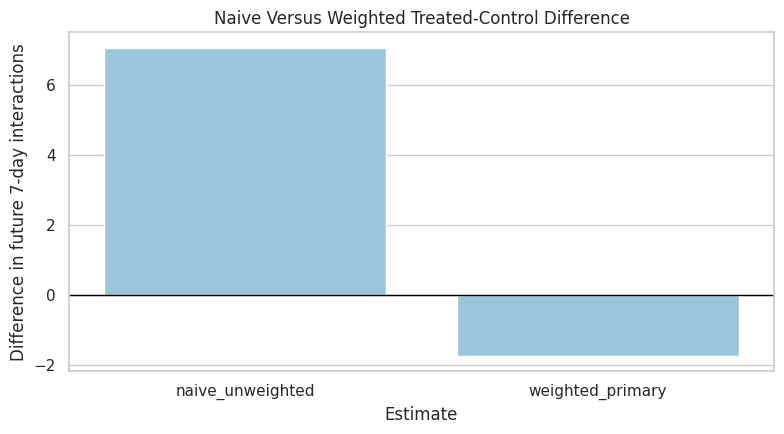

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=mean_difference_table, x="estimate", y="difference", ax=ax, color="#8ECAE6")
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Naive Versus Weighted Treated-Control Difference")
ax.set_xlabel("Estimate")
ax.set_ylabel("Difference in future 7-day interactions")
plt.tight_layout()
plt.show()


The plot turns the adjustment into a simple visual story. If the weighted bar differs meaningfully from the naive bar, then the treatment-assignment weights are materially changing the estimated long-term effect.


#### Build MSM Design Matrices

The marginal structural model can be simple or include calendar controls. The primary MSM is `outcome ~ treatment` in the weighted pseudo-population. A secondary calendar-adjusted MSM adds calendar day and day-of-week controls to absorb broad time patterns.

These calendar controls capture time patterns separately from user-history confounders. The history adjustment is already handled by the weights.


In [9]:
# Build MSM design matrices.
DAY_LEVELS = sorted(panel["day_of_week"].dropna().unique())
REFERENCE_DAY = DAY_LEVELS[0]


def build_design_matrix(data, include_calendar=False):
    """
    Build the MSM regression design matrix.
    
    Idea
    ----
    The matrix includes treatment and optional calendar controls so weighted least squares can estimate the marginal exposure effect.
    
    Parameters
    ----------
    data : object
        Input analysis table for the current project step.
    include_calendar : object
        Whether to include calendar controls in the model.
    
    Returns
    -------
    pandas.DataFrame
        Design matrix aligned with the input panel.
    """
    X = pd.DataFrame(
        {
            "const": 1.0,
            "treatment": data[PRIMARY_TREATMENT].astype(float).to_numpy(),
        },
        index=data.index,
    )

    if include_calendar:
        X["calendar_day_index"] = data["calendar_day_index"].astype(float).to_numpy()
        for day in DAY_LEVELS:
            if day == REFERENCE_DAY:
                continue
            X[f"day_of_week_{day}"] = (data["day_of_week"] == day).astype(float).to_numpy()

    return X.astype(float)

simple_design = build_design_matrix(panel, include_calendar=False)
calendar_design = build_design_matrix(panel, include_calendar=True)

print(f"Reference day for day-of-week dummies: {REFERENCE_DAY}")
print(f"Simple design columns: {simple_design.columns.tolist()}")
print(f"Calendar-adjusted design columns: {calendar_design.columns.tolist()}")


Reference day for day-of-week dummies: Friday
Simple design columns: ['const', 'treatment']
Calendar-adjusted design columns: ['const', 'treatment', 'calendar_day_index', 'day_of_week_Monday', 'day_of_week_Saturday', 'day_of_week_Sunday', 'day_of_week_Thursday', 'day_of_week_Tuesday', 'day_of_week_Wednesday']


The design matrices are ready for weighted regression. The simple design estimates the marginal treatment contrast directly, while the calendar-adjusted design checks whether broad time patterns change the treatment coefficient.


#### Fit Weighted Least-Squares MSMs with User-Cluster Robust Standard Errors

The next helper fits weighted least squares and extracts the treatment coefficient. Because each user appears on many days, the standard errors are clustered by `user_id`. This makes uncertainty more realistic than treating every row as independent.


In [10]:
# Fit weighted least-Squares MSMs with user-Cluster robust standard errors.
def fit_wls_msm(data, outcome_col, weight_col=None, include_calendar=False, model_name="model"):
    """
    Fit a weighted least-squares marginal structural model.
    
    Idea
    ----
    The function estimates the treatment coefficient for one outcome under a selected weight column and optional calendar adjustment.
    
    Parameters
    ----------
    data : object
        Input analysis table for the current project step.
    outcome_col : object
        Outcome column used in the estimator.
    weight_col : object
        Column containing observation weights.
    include_calendar : object
        Whether to include calendar controls in the model.
    model_name : object
        Label identifying the model family or specification.
    
    Returns
    -------
    dict
        Model name, treatment estimate, standard error, confidence interval, and diagnostics.
    """
    y = data[outcome_col].astype(float)
    X = build_design_matrix(data, include_calendar=include_calendar)

    if weight_col is None:
        model = sm.OLS(y, X)
    else:
        model = sm.WLS(y, X, weights=data[weight_col].astype(float))

    fitted = model.fit()
    robust = fitted.get_robustcov_results(cov_type="cluster", groups=data["user_id"])

    param_names = list(X.columns)
    treatment_idx = param_names.index("treatment")
    coef = float(robust.params[treatment_idx])
    se = float(robust.bse[treatment_idx])
    p_value = float(robust.pvalues[treatment_idx])
    ci_low, ci_high = robust.conf_int(alpha=0.05)[treatment_idx]

    control_mean = (
        data.loc[data[PRIMARY_TREATMENT].eq(0), outcome_col].mean()
        if weight_col is None
        else weighted_mean(
            data.loc[data[PRIMARY_TREATMENT].eq(0), outcome_col],
            data.loc[data[PRIMARY_TREATMENT].eq(0), weight_col],
        )
    )

    return {
        "model": model_name,
        "outcome": outcome_col,
        "weight_column": weight_col or "none",
        "include_calendar": include_calendar,
        "n_rows": len(data),
        "n_users": data["user_id"].nunique(),
        "control_mean": control_mean,
        "treatment_effect": coef,
        "relative_lift_vs_control": coef / control_mean if control_mean != 0 else np.nan,
        "cluster_robust_se": se,
        "ci_95_lower": float(ci_low),
        "ci_95_upper": float(ci_high),
        "p_value": p_value,
        "r_squared": float(fitted.rsquared),
    }

print("Defined MSM fitting helper with user-cluster robust standard errors.")


Defined MSM fitting helper with user-cluster robust standard errors.


The MSM helper packages the model fit and uncertainty extraction into one reusable function. Every main and sensitivity model below will report the same set of quantities, which makes the results comparable.


### Estimate Main MSM Specifications

This cell fits four core models:

- naive unweighted simple regression;
- weighted simple MSM;
- weighted calendar-adjusted MSM;
- weighted log-outcome MSM.

The weighted simple model is the primary MSM estimate. The calendar-adjusted and log-outcome models are robustness checks.


In [11]:
main_model_specs = [
    {"model_name": "naive_ols_simple", "outcome": PRIMARY_OUTCOME, "weight": None, "calendar": False},
    {"model_name": "msm_weighted_simple", "outcome": PRIMARY_OUTCOME, "weight": PRIMARY_WEIGHT, "calendar": False},
    {"model_name": "msm_weighted_calendar", "outcome": PRIMARY_OUTCOME, "weight": PRIMARY_WEIGHT, "calendar": True},
    {"model_name": "msm_weighted_log_outcome", "outcome": "outcome_log1p", "weight": PRIMARY_WEIGHT, "calendar": True},
]

main_results = pd.DataFrame(
    [
        fit_wls_msm(
            panel,
            outcome_col=spec["outcome"],
            weight_col=spec["weight"],
            include_calendar=spec["calendar"],
            model_name=spec["model_name"],
        )
        for spec in main_model_specs
    ]
)

display(main_results)


,model,outcome,weight_column,include_calendar,n_rows,n_users,control_mean,treatment_effect,relative_lift_vs_control,cluster_robust_se,ci_95_lower,ci_95_upper,p_value,r_squared
0,naive_ols_simple,outcome,none,False,4698,91,378.5479,7.0755,0.0187,7.3094,-7.4458,21.5968,0.3356,0.0005
1,msm_weighted_simple,outcome,analysis_weight,False,4698,91,375.1457,-1.7389,-0.0046,5.9348,-13.5295,10.0517,0.7702,0.0000
2,msm_weighted_calendar,outcome,analysis_weight,True,4698,91,375.1457,-2.6877,-0.0072,4.5962,-11.8189,6.4435,0.5602,0.4727
3,msm_weighted_log_outcome,outcome_log1p,analysis_weight,True,4698,91,5.8130,-0.0120,-0.0021,0.0148,-0.0414,0.0175,0.4220,0.5182


The main results table is the first formal causal estimate in this long-term causal effects workflow. The key row is `msm_weighted_simple`; the other rows show whether the conclusion changes under an unweighted analysis, calendar adjustment, or a log-transformed outcome.


#### Plot Main MSM Estimates

This plot shows the treatment-effect estimates and cluster-robust confidence intervals for the main count-outcome models. The log-outcome model is excluded because it is on a different scale.


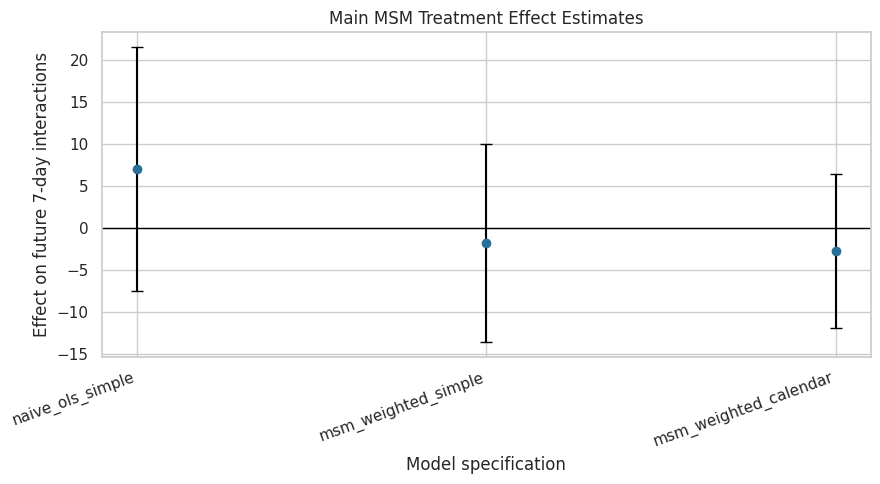

In [12]:
plot_main = main_results.query("outcome == @PRIMARY_OUTCOME").copy()
plot_main["lower_error"] = plot_main["treatment_effect"] - plot_main["ci_95_lower"]
plot_main["upper_error"] = plot_main["ci_95_upper"] - plot_main["treatment_effect"]

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(
    x=np.arange(len(plot_main)),
    y=plot_main["treatment_effect"],
    yerr=[plot_main["lower_error"], plot_main["upper_error"]],
    fmt="o",
    color="#2A6F97",
    ecolor="black",
    capsize=4,
)
ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(np.arange(len(plot_main)))
ax.set_xticklabels(plot_main["model"], rotation=20, ha="right")
ax.set_title("Main MSM Treatment Effect Estimates")
ax.set_ylabel("Effect on future 7-day interactions")
ax.set_xlabel("Model specification")
plt.tight_layout()
plt.show()


The plot shows whether the estimated effect remains similar after weighting and calendar adjustment. Confidence intervals crossing zero indicate that the estimate is uncertain even if the point estimate has a clear sign.


### User-Cluster Bootstrap for the Primary MSM

Cluster-robust standard errors are useful. A user-cluster bootstrap gives another uncertainty check. The bootstrap resamples whole users so it respects the fact that each user contributes many days.

The bootstrap below estimates the calendar-adjusted weighted MSM repeatedly on resampled users.


In [13]:
# Prepare user-Cluster bootstrap for the primary MSM.
def fit_wls_treatment_coef(data, outcome_col, weight_col, include_calendar=True):
    """
    Fit a WLS model and return the treatment coefficient.
    
    Idea
    ----
    This compact helper is used inside bootstrap or sensitivity loops where only the treatment effect estimate is needed.
    
    Parameters
    ----------
    data : object
        Input analysis table for the current project step.
    outcome_col : object
        Outcome column used in the estimator.
    weight_col : object
        Column containing observation weights.
    include_calendar : object
        Whether to include calendar controls in the model.
    
    Returns
    -------
    float
        Estimated treatment coefficient from the weighted model.
    """
    y = data[outcome_col].astype(float).to_numpy()
    X = build_design_matrix(data, include_calendar=include_calendar).to_numpy(dtype=float)
    weights = data[weight_col].astype(float).to_numpy()
    sqrt_w = np.sqrt(weights)
    coef = np.linalg.lstsq(X * sqrt_w[:, None], y * sqrt_w, rcond=None)[0]
    treatment_idx = list(build_design_matrix(data, include_calendar=include_calendar).columns).index("treatment")
    return float(coef[treatment_idx])

N_BOOTSTRAP = 300
rng = np.random.default_rng(RANDOM_STATE)
user_ids = panel["user_id"].unique()
user_groups = {user_id: group.copy() for user_id, group in panel.groupby("user_id", sort=False)}

bootstrap_effects = []
for bootstrap_id in range(N_BOOTSTRAP):
    sampled_users = rng.choice(user_ids, size=len(user_ids), replace=True)
    bootstrap_sample = pd.concat(
        [user_groups[user_id] for user_id in sampled_users],
        ignore_index=True,
    )
    effect = fit_wls_treatment_coef(
        bootstrap_sample,
        outcome_col=PRIMARY_OUTCOME,
        weight_col=PRIMARY_WEIGHT,
        include_calendar=True,
    )
    bootstrap_effects.append(effect)

bootstrap_results = pd.DataFrame(
    {
        "bootstrap_id": np.arange(N_BOOTSTRAP),
        "treatment_effect": bootstrap_effects,
    }
)

bootstrap_summary = pd.Series(
    {
        "bootstrap_reps": N_BOOTSTRAP,
        "mean": bootstrap_results["treatment_effect"].mean(),
        "std": bootstrap_results["treatment_effect"].std(ddof=1),
        "ci_95_lower": bootstrap_results["treatment_effect"].quantile(0.025),
        "ci_95_upper": bootstrap_results["treatment_effect"].quantile(0.975),
    }
).rename("value")

display(bootstrap_summary)


bootstrap_reps   300.0000
mean              -3.1970
std                4.6352
ci_95_lower      -12.2706
ci_95_upper        5.7291
Name: value, dtype: float64

The bootstrap summary gives a second uncertainty estimate for the primary calendar-adjusted MSM. Because users are resampled as clusters, this uncertainty check is aligned with the panel structure of the data.


#### Plot the Bootstrap Distribution

The bootstrap distribution shows how much the treatment-effect estimate moves across resampled user populations. A wide distribution means the estimate is sensitive to which users appear in the sample.


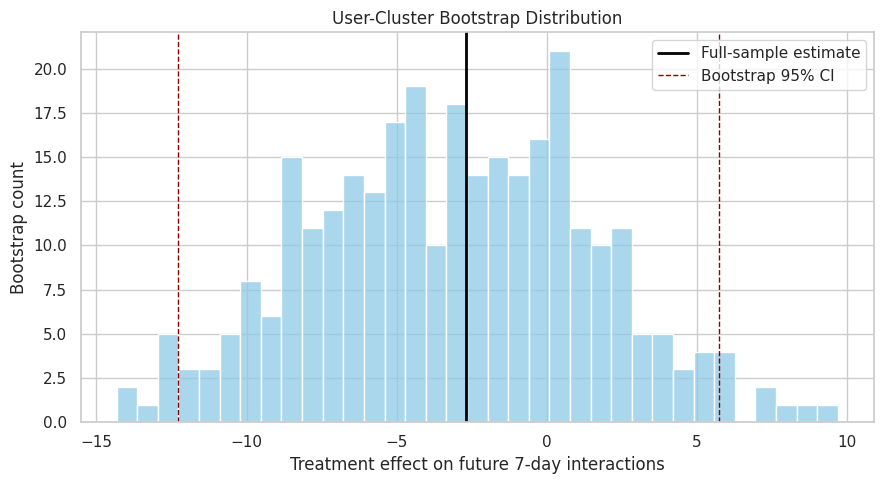

In [14]:
primary_calendar_effect = main_results.loc[
    main_results["model"].eq("msm_weighted_calendar"),
    "treatment_effect",
].iloc[0]

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(data=bootstrap_results, x="treatment_effect", bins=35, color="#8ECAE6", ax=ax)
ax.axvline(primary_calendar_effect, color="black", linewidth=2, label="Full-sample estimate")
ax.axvline(bootstrap_summary["ci_95_lower"], color="darkred", linestyle="--", linewidth=1, label="Bootstrap 95% CI")
ax.axvline(bootstrap_summary["ci_95_upper"], color="darkred", linestyle="--", linewidth=1)
ax.set_title("User-Cluster Bootstrap Distribution")
ax.set_xlabel("Treatment effect on future 7-day interactions")
ax.set_ylabel("Bootstrap count")
ax.legend()
plt.tight_layout()
plt.show()


The bootstrap plot makes uncertainty tangible. If the distribution spans both positive and negative effects, the project should report the estimate as uncertain.


### Weight-Choice Sensitivity

Notebook 03 showed that overlap was imperfect and weights reduced effective sample size. This cell checks whether the MSM estimate depends on the weight version: unclipped logistic weights, clipped logistic weights, and LightGBM weights.


In [15]:
# Weight-Choice sensitivity.
panel["sw_lightgbm_clip_10"] = panel["sw_lightgbm"].clip(upper=10)

weight_sensitivity_specs = [
    {"model_name": "unweighted", "weight": None},
    {"model_name": "logistic_stabilized_unclipped", "weight": "sw_logistic"},
    {"model_name": "logistic_stabilized_clip_10", "weight": "analysis_weight"},
    {"model_name": "logistic_stabilized_clip_5", "weight": "sw_logistic_clip_5"},
    {"model_name": "logistic_stabilized_clip_2", "weight": "sw_logistic_clip_2"},
    {"model_name": "lightgbm_stabilized_unclipped", "weight": "sw_lightgbm"},
    {"model_name": "lightgbm_stabilized_clip_10", "weight": "sw_lightgbm_clip_10"},
]

weight_sensitivity = pd.DataFrame(
    [
        fit_wls_msm(
            panel,
            outcome_col=PRIMARY_OUTCOME,
            weight_col=spec["weight"],
            include_calendar=True,
            model_name=spec["model_name"],
        )
        for spec in weight_sensitivity_specs
    ]
)

weight_sensitivity["effective_sample_size"] = [
    len(panel) if spec["weight"] is None else effective_sample_size(panel[spec["weight"]])
    for spec in weight_sensitivity_specs
]
weight_sensitivity["ess_share_of_rows"] = weight_sensitivity["effective_sample_size"] / len(panel)

display(weight_sensitivity)


,model,outcome,weight_column,include_calendar,n_rows,n_users,control_mean,treatment_effect,relative_lift_vs_control,cluster_robust_se,ci_95_lower,ci_95_upper,p_value,r_squared,effective_sample_size,ess_share_of_rows
0,unweighted,outcome,none,True,4698,91,378.5479,-2.6193,-0.0069,4.4940,-11.5474,6.3088,0.5615,0.4363,"4,698.0000",1.0000
1,logistic_stabilized_unclipped,outcome,sw_logistic,True,4698,91,375.6858,1.5616,0.0042,8.2328,-14.7943,17.9175,0.8500,0.4709,"1,260.0838",0.2682
2,logistic_stabilized_clip_10,outcome,analysis_weight,True,4698,91,375.1457,-2.6877,-0.0072,4.5962,-11.8189,6.4435,0.5602,0.4727,"2,400.8979",0.5110
3,logistic_stabilized_clip_5,outcome,sw_logistic_clip_5,True,4698,91,375.1266,-2.9769,-0.0079,4.1279,-11.1777,5.2239,0.4727,0.4690,"2,932.2499",0.6241
4,logistic_stabilized_clip_2,outcome,sw_logistic_clip_2,True,4698,91,376.3357,-2.2273,-0.0059,3.8445,-9.8650,5.4105,0.5638,0.4593,"3,797.3068",0.8083
5,lightgbm_stabilized_unclipped,outcome,sw_lightgbm,True,4698,91,380.0789,0.9744,0.0026,4.8031,-8.5678,10.5166,0.8397,0.4501,"2,143.4028",0.4562
6,lightgbm_stabilized_clip_10,outcome,sw_lightgbm_clip_10,True,4698,91,380.8991,-0.4889,-0.0013,4.5072,-9.4432,8.4655,0.9139,0.4520,"2,351.8214",0.5006


The sensitivity table shows whether the treatment estimate is stable across reasonable weighting choices. Large shifts across weight versions would mean the causal conclusion depends heavily on overlap and clipping decisions.


#### Plot Weight Sensitivity

The plot below shows treatment-effect estimates across weight choices. It includes confidence intervals from user-cluster robust standard errors.


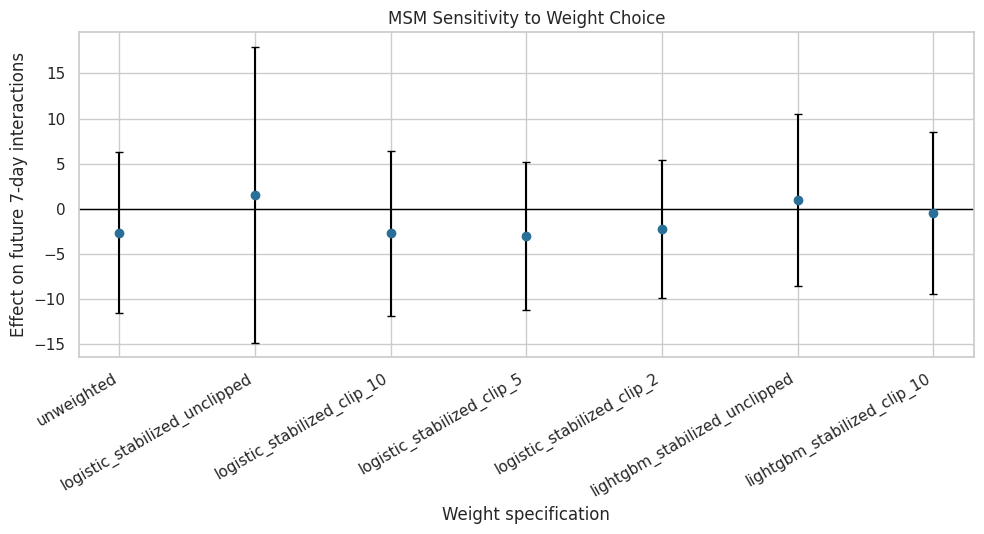

In [16]:
weight_plot = weight_sensitivity.copy()
weight_plot["lower_error"] = weight_plot["treatment_effect"] - weight_plot["ci_95_lower"]
weight_plot["upper_error"] = weight_plot["ci_95_upper"] - weight_plot["treatment_effect"]

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.errorbar(
    x=np.arange(len(weight_plot)),
    y=weight_plot["treatment_effect"],
    yerr=[weight_plot["lower_error"], weight_plot["upper_error"]],
    fmt="o",
    color="#2A6F97",
    ecolor="black",
    capsize=3,
)
ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(np.arange(len(weight_plot)))
ax.set_xticklabels(weight_plot["model"], rotation=30, ha="right")
ax.set_title("MSM Sensitivity to Weight Choice")
ax.set_ylabel("Effect on future 7-day interactions")
ax.set_xlabel("Weight specification")
plt.tight_layout()
plt.show()


This plot is the main robustness view for the MSM estimate. If the estimates cluster together, the result is less dependent on the exact propensity model; if they spread out, the conclusion should emphasize sensitivity.


### Secondary Outcome Sensitivity

The primary outcome is future 7-day interaction volume. This cell repeats the weighted calendar-adjusted MSM for secondary outcomes: future active days, average daily interactions, watch hours, and the log-transformed interaction outcome.


In [17]:
secondary_outcomes = [
    "future_7day_active_days",
    "future_7day_avg_daily_interactions",
    "future_7day_play_hours",
    "outcome_log1p",
]

secondary_results = pd.DataFrame(
    [
        fit_wls_msm(
            panel,
            outcome_col=outcome_col,
            weight_col=PRIMARY_WEIGHT,
            include_calendar=True,
            model_name=f"msm_weighted_calendar_{outcome_col}",
        )
        for outcome_col in secondary_outcomes
    ]
)

display(secondary_results)


,model,outcome,weight_column,include_calendar,n_rows,n_users,control_mean,treatment_effect,relative_lift_vs_control,cluster_robust_se,ci_95_lower,ci_95_upper,p_value,r_squared
0,msm_weighted_calendar_future_7day_active_days,future_7day_active_days,analysis_weight,True,4698,91,6.8748,-0.0299,-0.0044,0.0190,-0.0677,0.0079,0.1194,0.0099
1,msm_weighted_calendar_future_7day_avg_daily_in...,future_7day_avg_daily_interactions,analysis_weight,True,4698,91,53.5922,-0.3840,-0.0072,0.6566,-1.6884,0.9205,0.5602,0.4727
2,msm_weighted_calendar_future_7day_play_hours,future_7day_play_hours,analysis_weight,True,4698,91,0.8679,0.0598,0.0689,0.0195,0.0210,0.0986,0.0029,0.3471
3,msm_weighted_calendar_outcome_log1p,outcome_log1p,analysis_weight,True,4698,91,5.8130,-0.0120,-0.0021,0.0148,-0.0414,0.0175,0.4220,0.5182


The secondary outcome results show whether the estimated treatment effect appears only for interaction volume or also for broader retention and watch-time metrics. This helps keep the product interpretation balanced.


#### Plot Secondary Outcome Effects

The secondary outcomes live on different scales, so each estimate should be interpreted in its own units. The plot is still useful for direction and uncertainty.


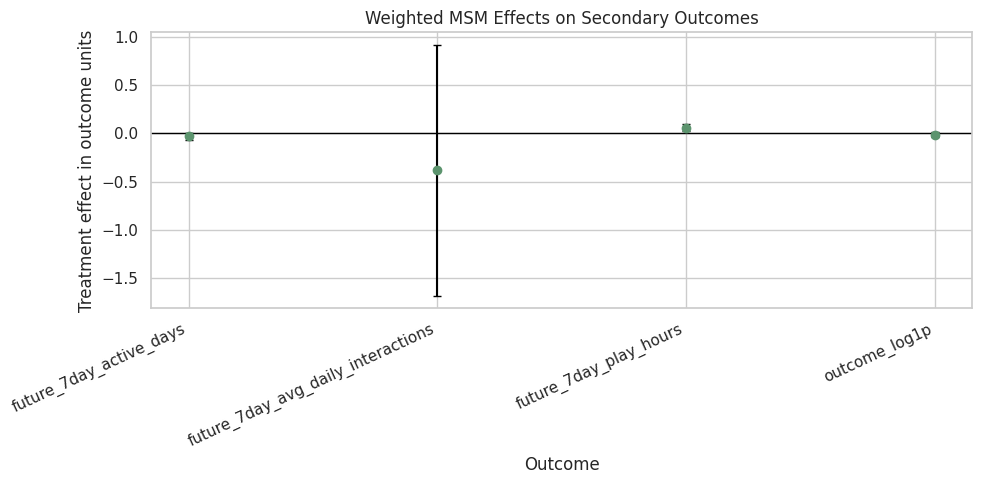

In [18]:
secondary_plot = secondary_results.copy()
secondary_plot["lower_error"] = secondary_plot["treatment_effect"] - secondary_plot["ci_95_lower"]
secondary_plot["upper_error"] = secondary_plot["ci_95_upper"] - secondary_plot["treatment_effect"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(
    x=np.arange(len(secondary_plot)),
    y=secondary_plot["treatment_effect"],
    yerr=[secondary_plot["lower_error"], secondary_plot["upper_error"]],
    fmt="o",
    color="#5C946E",
    ecolor="black",
    capsize=3,
)
ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(np.arange(len(secondary_plot)))
ax.set_xticklabels(secondary_plot["outcome"], rotation=25, ha="right")
ax.set_title("Weighted MSM Effects on Secondary Outcomes")
ax.set_ylabel("Treatment effect in outcome units")
ax.set_xlabel("Outcome")
plt.tight_layout()
plt.show()


The secondary plot checks whether the long-term story is consistent across engagement definitions. Mixed directions or wide intervals would suggest that the primary outcome should be reported carefully.


#### Translate the Primary Estimate into Product Language

This cell converts the primary MSM result into a short, readable statement. It reports the treatment effect in future interactions and as a relative lift against the weighted control mean.


In [19]:
# Translate the primary estimate into product language.
primary_result = main_results.query("model == 'msm_weighted_calendar'").iloc[0]
primary_statement = pd.DataFrame(
    [
        {
            "quantity": "weighted_control_mean_future_7day_interactions",
            "value": primary_result["control_mean"],
        },
        {
            "quantity": "estimated_incremental_future_7day_interactions",
            "value": primary_result["treatment_effect"],
        },
        {
            "quantity": "relative_lift_vs_weighted_control_mean",
            "value": primary_result["relative_lift_vs_control"],
        },
        {
            "quantity": "cluster_robust_ci_lower",
            "value": primary_result["ci_95_lower"],
        },
        {
            "quantity": "cluster_robust_ci_upper",
            "value": primary_result["ci_95_upper"],
        },
        {
            "quantity": "bootstrap_ci_lower",
            "value": bootstrap_summary["ci_95_lower"],
        },
        {
            "quantity": "bootstrap_ci_upper",
            "value": bootstrap_summary["ci_95_upper"],
        },
    ]
)

display(primary_statement)


,quantity,value
0,weighted_control_mean_future_7day_interactions,375.1457
1,estimated_incremental_future_7day_interactions,-2.6877
2,relative_lift_vs_weighted_control_mean,-0.0072
3,cluster_robust_ci_lower,-11.8189
4,cluster_robust_ci_upper,6.4435
5,bootstrap_ci_lower,-12.2706
6,bootstrap_ci_upper,5.7291


This table is the stakeholder-readable version of the primary result. It gives the estimated incremental effect, its relative size, and two uncertainty views that should inform the project conclusion.


#### Create a Compact MSM Results Table

The compact results table combines the main models, weight sensitivity, secondary outcomes, and bootstrap interval. It gives the next notebooks a single place to compare the MSM evidence.


In [20]:
main_results_labeled = main_results.assign(result_family="main_msm")
weight_sensitivity_labeled = weight_sensitivity.assign(result_family="weight_sensitivity")
secondary_results_labeled = secondary_results.assign(result_family="secondary_outcome")

msm_results = pd.concat(
    [main_results_labeled, weight_sensitivity_labeled, secondary_results_labeled],
    ignore_index=True,
    sort=False,
)

msm_results["is_primary_result"] = msm_results["model"].eq("msm_weighted_calendar") & msm_results["outcome"].eq(PRIMARY_OUTCOME)

bootstrap_interval = pd.DataFrame(
    [
        {
            "model": "msm_weighted_calendar",
            "outcome": PRIMARY_OUTCOME,
            "bootstrap_reps": int(N_BOOTSTRAP),
            "bootstrap_mean": bootstrap_summary["mean"],
            "bootstrap_std": bootstrap_summary["std"],
            "bootstrap_ci_95_lower": bootstrap_summary["ci_95_lower"],
            "bootstrap_ci_95_upper": bootstrap_summary["ci_95_upper"],
        }
    ]
)

display(msm_results.head(20))
display(bootstrap_interval)


,model,outcome,weight_column,include_calendar,n_rows,n_users,control_mean,treatment_effect,relative_lift_vs_control,cluster_robust_se,ci_95_lower,ci_95_upper,p_value,r_squared,result_family,effective_sample_size,ess_share_of_rows,is_primary_result
0,naive_ols_simple,outcome,none,False,4698,91,378.5479,7.0755,0.0187,7.3094,-7.4458,21.5968,0.3356,0.0005,main_msm,NaN,NaN,False
1,msm_weighted_simple,outcome,analysis_weight,False,4698,91,375.1457,-1.7389,-0.0046,5.9348,-13.5295,10.0517,0.7702,0.0000,main_msm,NaN,NaN,False
2,msm_weighted_calendar,outcome,analysis_weight,True,4698,91,375.1457,-2.6877,-0.0072,4.5962,-11.8189,6.4435,0.5602,0.4727,main_msm,NaN,NaN,True
3,msm_weighted_log_outcome,outcome_log1p,analysis_weight,True,4698,91,5.8130,-0.0120,-0.0021,0.0148,-0.0414,0.0175,0.4220,0.5182,main_msm,NaN,NaN,False
4,unweighted,outcome,none,True,4698,91,378.5479,-2.6193,-0.0069,4.4940,-11.5474,6.3088,0.5615,0.4363,weight_sensitivity,"4,698.0000",1.0000,False
5,logistic_stabilized_unclipped,outcome,sw_logistic,True,4698,91,375.6858,1.5616,0.0042,8.2328,-14.7943,17.9175,0.8500,0.4709,weight_sensitivity,"1,260.0838",0.2682,False
6,logistic_stabilized_clip_10,outcome,analysis_weight,True,4698,91,375.1457,-2.6877,-0.0072,4.5962,-11.8189,6.4435,0.5602,0.4727,weight_sensitivity,"2,400.8979",0.5110,False
7,logistic_stabilized_clip_5,outcome,sw_logistic_clip_5,True,4698,91,375.1266,-2.9769,-0.0079,4.1279,-11.1777,5.2239,0.4727,0.4690,weight_sensitivity,"2,932.2499",0.6241,False
8,logistic_stabilized_clip_2,outcome,sw_logistic_clip_2,True,4698,91,376.3357,-2.2273,-0.0059,3.8445,-9.8650,5.4105,0.5638,0.4593,weight_sensitivity,"3,797.3068",0.8083,False
9,lightgbm_stabilized_unclipped,outcome,sw_lightgbm,True,4698,91,380.0789,0.9744,0.0026,4.8031,-8.5678,10.5166,0.8397,0.4501,weight_sensitivity,"2,143.4028",0.4562,False


,model,outcome,bootstrap_reps,bootstrap_mean,bootstrap_std,bootstrap_ci_95_lower,bootstrap_ci_95_upper
0,msm_weighted_calendar,outcome,300,-3.1970,4.6352,-12.2706,5.7291


The combined table gathers the evidence needed for reporting: the main effect, sensitivity to weights, and secondary outcome checks. The separate bootstrap interval keeps the cluster-resampling uncertainty explicit.


In [21]:
msm_results_path = PROCESSED_DIR / "kuairec_long_term_msm_results.csv"
msm_primary_statement_path = PROCESSED_DIR / "kuairec_long_term_msm_primary_statement.csv"
msm_bootstrap_path = PROCESSED_DIR / "kuairec_long_term_msm_bootstrap_distribution.csv"
msm_bootstrap_interval_path = PROCESSED_DIR / "kuairec_long_term_msm_bootstrap_interval.csv"
msm_weight_sensitivity_path = PROCESSED_DIR / "kuairec_long_term_msm_weight_sensitivity.csv"
msm_secondary_outcomes_path = PROCESSED_DIR / "kuairec_long_term_msm_secondary_outcomes.csv"

msm_results.to_csv(msm_results_path, index=False)
primary_statement.to_csv(msm_primary_statement_path, index=False)
bootstrap_results.to_csv(msm_bootstrap_path, index=False)
bootstrap_interval.to_csv(msm_bootstrap_interval_path, index=False)
weight_sensitivity.to_csv(msm_weight_sensitivity_path, index=False)
secondary_results.to_csv(msm_secondary_outcomes_path, index=False)

print("Saved Notebook 04 outputs:")
print(f"- {msm_results_path}")
print(f"- {msm_primary_statement_path}")
print(f"- {msm_bootstrap_path}")
print(f"- {msm_bootstrap_interval_path}")
print(f"- {msm_weight_sensitivity_path}")
print(f"- {msm_secondary_outcomes_path}")


The MSM estimates are now organized for comparison. The next notebook can focus on g-computation as a complementary causal estimation strategy.


## Takeaways and Next Step

This notebook estimated the primary long-term causal effect with a marginal structural model. The key idea was to use the stabilized inverse probability weights from Notebook 03 to estimate the treatment effect in a weighted pseudo-population where observed pre-treatment histories are more balanced.

The final interpretation should include both the point estimate and uncertainty. Because overlap was imperfect in Notebook 03, the weight-sensitivity and bootstrap results are central evidence for judging how much confidence to place in the MSM estimate.

The next notebook should implement **g-computation**. That will estimate future outcomes by modeling the outcome surface directly, then simulating each user-day under treatment and control. Comparing g-computation with the MSM result checks whether two different causal strategies tell a similar story.
